# Chapter 6 — Flow Matching (CFM) on MNIST (28×28)

**Theory reference**: `quickguide.tex` Chapter 4.

### What this notebook covers
1. **Train CFM** on MNIST using `SmallUNet` as the velocity network
2. **ODE sampling** — Euler solver, NFE sweep {10, 20, 50, 100}
3. **RK4 vs. Euler** comparison at equal NFE
4. **ODE trajectories** — visualise intermediate states $x_t$ for $t\in[0,1]$
5. **Interpolation in source space** — morph between two generated digits
6. **CFM vs. DDIM-50** side-by-side quality comparison

### Key equations
**OT-Gaussian path** (quickguide §4.4):
$$x_t = (1-(1-\sigma_{\min})t)\,x_0 + t\,x_1, \qquad x_0 \sim \mathcal{N}(0,I),\; x_1 \sim p_{\text{data}}$$

**Conditional velocity** (constant along each path):
$$u_t(x_t|x_0,x_1) = x_1 - (1-\sigma_{\min})\,x_0$$

**CFM loss**:
$$\mathcal{L}_{\text{CFM}} = \mathbb{E}_{t,x_0,x_1}\bigl[\|v_\theta(x_t,t) - u_t(x_t|x_0,x_1)\|^2\bigr]$$

**ODE** (Euler step):
$$x_{t+\Delta t} = x_t + \Delta t\, v_\theta(x_t, t)$$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


## 0  Data

In [2]:
from diffusion_lab.data import get_mnist_loader, denormalize

train_loader = get_mnist_loader(split='train', batch_size=128, num_workers=0)
test_loader  = get_mnist_loader(split='test',  batch_size=64,  num_workers=0)

x_batch, _ = next(iter(train_loader))
print(f'Batch shape: {x_batch.shape}  range: [{x_batch.min():.2f}, {x_batch.max():.2f}]')

Batch shape: torch.Size([128, 1, 28, 28])  range: [-1.00, 1.00]


## 1  Build CFM model — SmallUNet as velocity network

Unlike DDPM, CFM learns a **velocity field** $v_\theta: \mathbb{R}^d \times [0,1] \to \mathbb{R}^d$,  
not a score or noise. The same `SmallUNet` architecture is reused with `out_channels=1`.

In [3]:
from diffusion_lab.nn     import SmallUNet
from diffusion_lab.models import CFM

vel_net = SmallUNet(
    in_channels=1,
    out_channels=1,
    base_channels=32,
    time_embed_dim=128,
    dropout=0.1,
).to(DEVICE)

cfm = CFM(
    network=vel_net,
    sigma_min=1e-4,
).to(DEVICE)

n_params = sum(p.numel() for p in vel_net.parameters())
print(f'Velocity network parameters: {n_params:,}  (~{n_params/1e6:.2f}M)')

Velocity network parameters: 1,590,017  (~1.59M)


## 2  Train CFM

CFM regression converges faster per step than DDPM because the target (velocity) has smaller
variance than noise prediction. The training loop is identical — model exposes `.loss(x1)`.

In [4]:
from diffusion_lab.training import Trainer

trainer = Trainer(
    model=cfm,
    loader=train_loader,
    lr=2e-4,
    weight_decay=0.0,
    grad_clip=1.0,
    device=DEVICE,
)

N_STEPS = 20_000   # ← reduce to 2000 for a quick smoke test
losses  = trainer.train(n_steps=N_STEPS, log_every=500)
print(f'Initial loss: {losses[0]:.4f}   Final loss: {losses[-1]:.4f}')

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial loss: 1.9191   Final loss: 0.1949


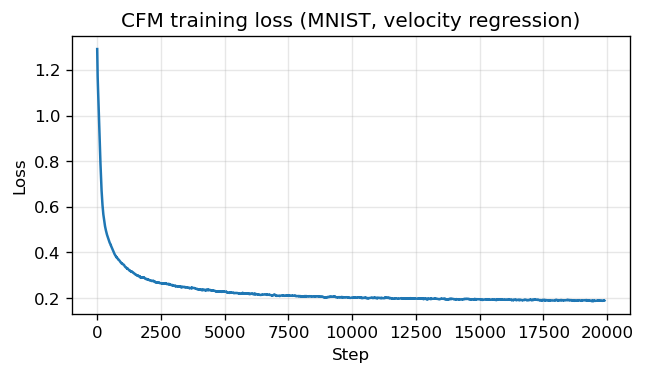

In [5]:
from diffusion_lab.utils import plot_loss_curve
plot_loss_curve(losses, smooth=100, title='CFM training loss (MNIST, velocity regression)')
plt.show()

## 3  ODE sampling — Euler, NFE sweep

Euler- 10: done
Euler- 20: done
Euler- 50: done
Euler-100: done


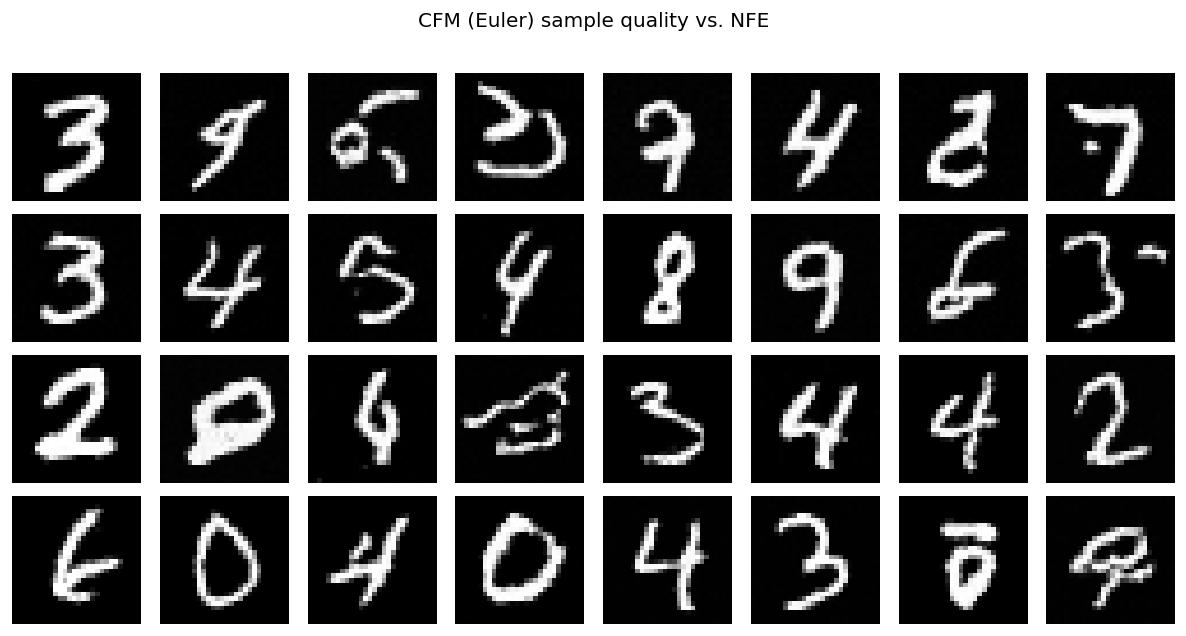

In [6]:
from diffusion_lab.utils import show_grid

cfm.eval()
nfe_list = [10, 20, 50, 100]
cfm_samples = {}

for nfe in nfe_list:
    with torch.no_grad():
        xs = cfm.sample(
            shape=(64, 1, 28, 28),
            device=DEVICE,
            n_steps=nfe,
            method='euler',
        )
    cfm_samples[nfe] = xs
    print(f'Euler-{nfe:3d}: done')

# Display all in one figure
fig, axes = plt.subplots(len(nfe_list), 8, figsize=(10, len(nfe_list)*1.3))
for row, nfe in enumerate(nfe_list):
    imgs = denormalize(cfm_samples[nfe][:8]).cpu().numpy()
    for col in range(8):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Euler-{nfe}', rotation=0, labelpad=48, va='center', fontsize=9)

fig.suptitle('CFM (Euler) sample quality vs. NFE', y=1.01)
plt.tight_layout()
plt.show()

## 4  RK4 vs. Euler at equal NFE

RK4 uses 4 network evaluations per step, so `n_steps=25` with RK4 costs the same
as `n_steps=100` with Euler in terms of NFE.

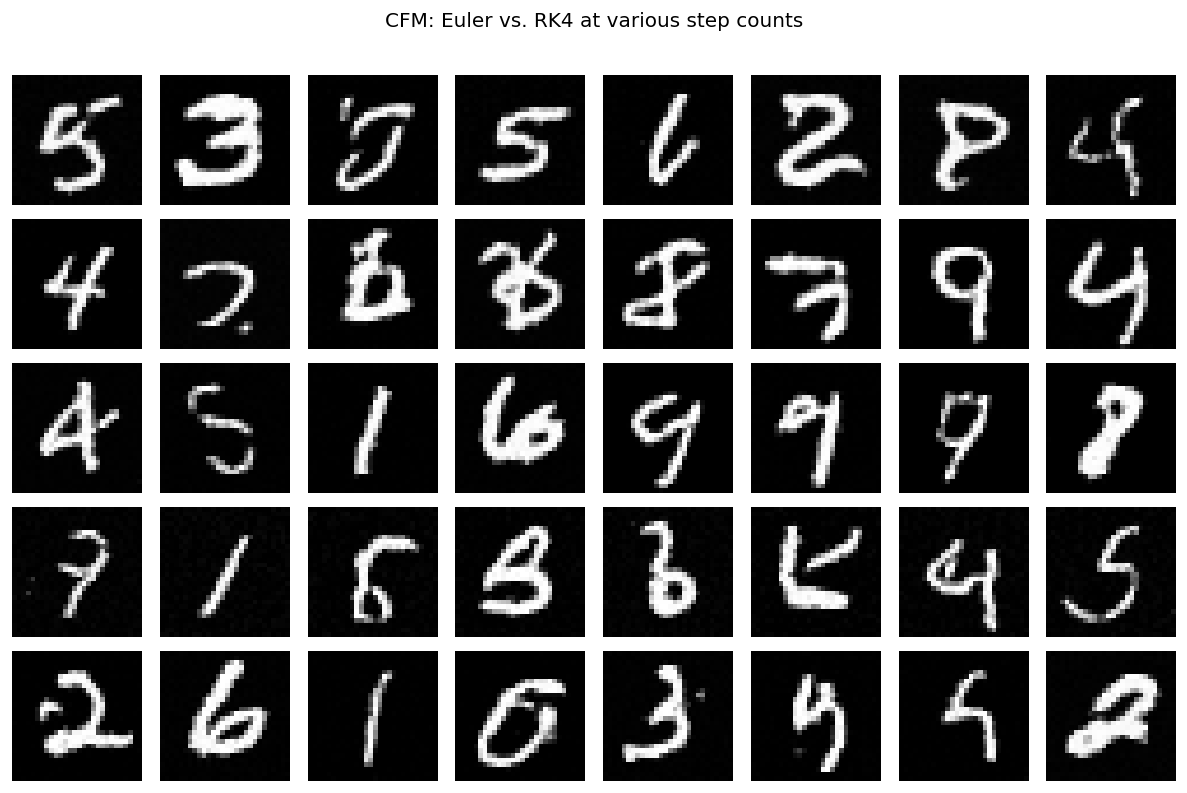

In [7]:
configs = [
    ('euler', 10),
    ('euler', 20),
    ('euler', 50),
    ('rk4',   10),   # 4×10 = 40 NFE
    ('rk4',   25),   # 4×25 = 100 NFE
]

fig, axes = plt.subplots(len(configs), 8, figsize=(10, len(configs)*1.3))

for row, (method, n_steps) in enumerate(configs):
    with torch.no_grad():
        xs = cfm.sample((8, 1, 28, 28), device=DEVICE, n_steps=n_steps, method=method)
    imgs = denormalize(xs).cpu().numpy()
    nfe  = n_steps * (4 if method == 'rk4' else 1)
    for col in range(8):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    label = f'{method.upper()}-{n_steps}\n(NFE={nfe})'
    axes[row, 0].set_ylabel(label, rotation=0, labelpad=60, va='center', fontsize=7.5)

fig.suptitle('CFM: Euler vs. RK4 at various step counts', y=1.01)
plt.tight_layout()
plt.show()

## 5  ODE trajectories — intermediate states $x_t$

Because CFM uses straight-line OT paths, the intermediate states should look like
linear interpolations between Gaussian noise and MNIST images.

Chain frames: 11


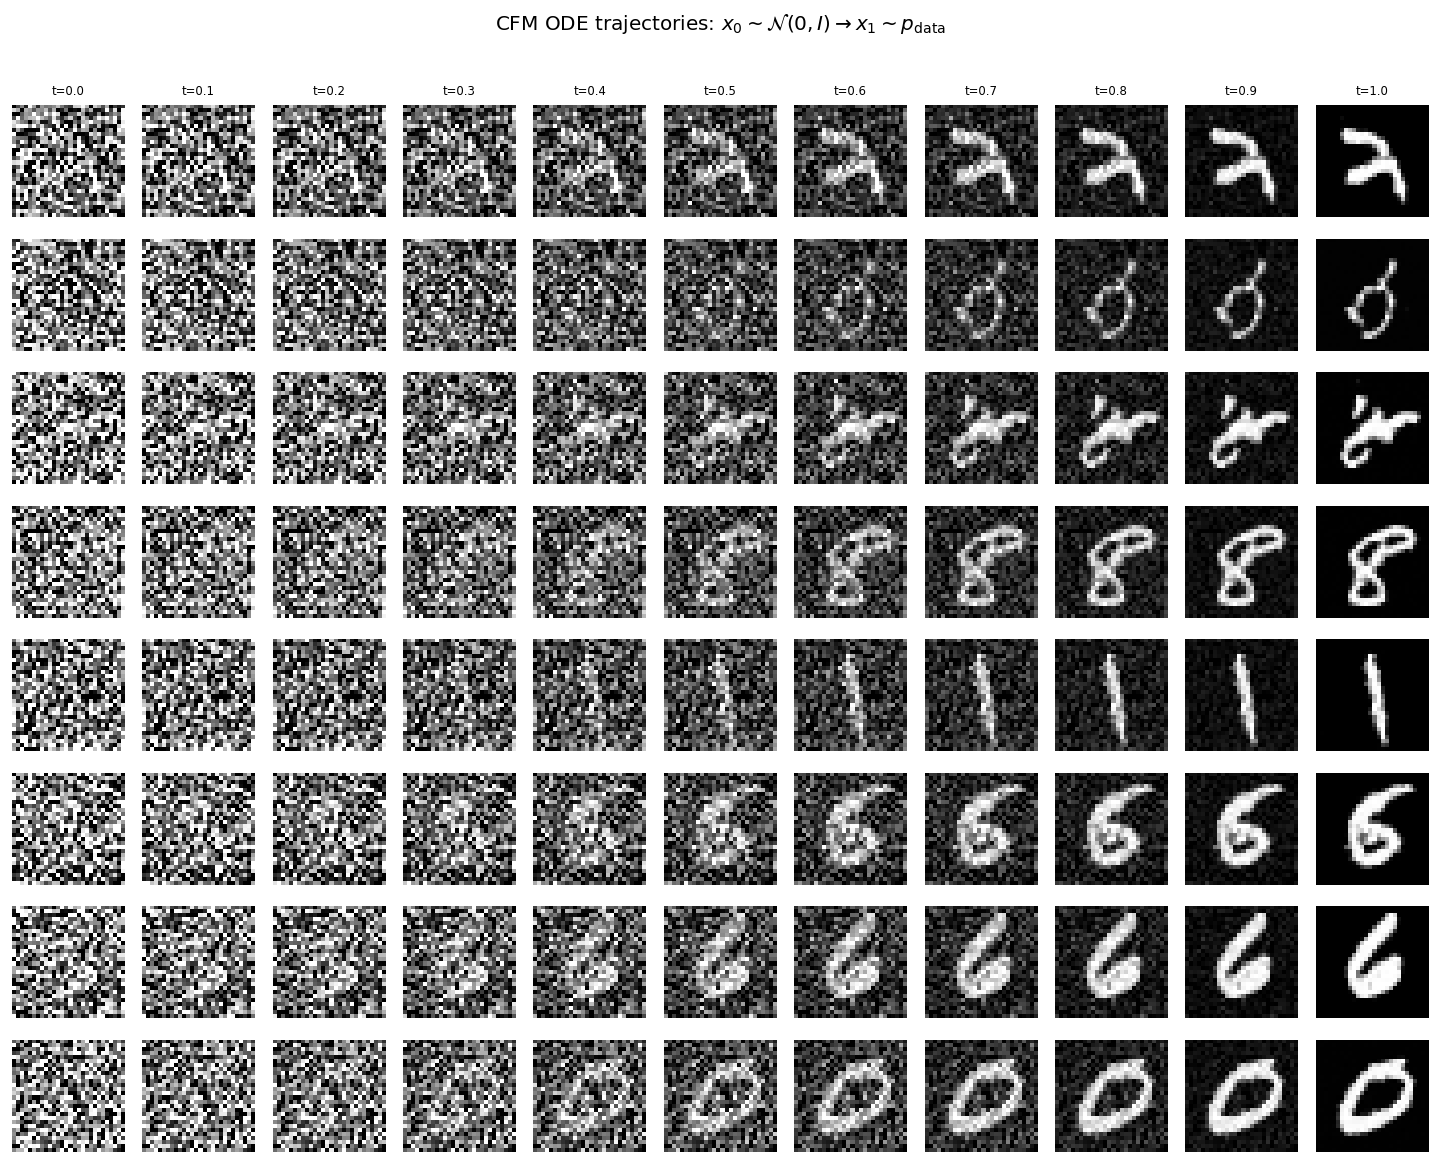

In [8]:
N_TRAJ = 8
torch.manual_seed(42)
x0_fixed = torch.randn(N_TRAJ, 1, 28, 28, device=DEVICE)

# Collect chain snapshots
with torch.no_grad():
    chain = cfm.sample(
        shape=(N_TRAJ, 1, 28, 28),
        device=DEVICE,
        n_steps=100,
        method='euler',
        return_chain=True,
        chain_stride=10,
    )

print(f'Chain frames: {len(chain)}')

# Plot: rows = samples, cols = t snapshots
n_frames = len(chain)
fig, axes = plt.subplots(N_TRAJ, n_frames, figsize=(n_frames * 1.1, N_TRAJ * 1.2))
t_labels  = [f't={i*10/100:.1f}' for i in range(n_frames)]

for col, (frame, tlabel) in enumerate(zip(chain, t_labels)):
    imgs = denormalize(frame).numpy()
    for row in range(N_TRAJ):
        axes[row, col].imshow(imgs[row, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(tlabel, fontsize=7)

fig.suptitle('CFM ODE trajectories: $x_0 \\sim \\mathcal{N}(0,I) \\to x_1 \\sim p_{\\text{data}}$', y=1.01)
plt.tight_layout()
plt.show()

## 6  Source-space interpolation

Sample two source points $z_A, z_B \sim \mathcal{N}(0,I)$ and interpolate:
$$z(\lambda) = (1-\lambda)\,z_A + \lambda\,z_B, \qquad \lambda\in[0,1]$$
then push each $z(\lambda)$ through the CFM ODE.  
Because CFM flow is approximately bijective, this traces a smooth path through digit space.

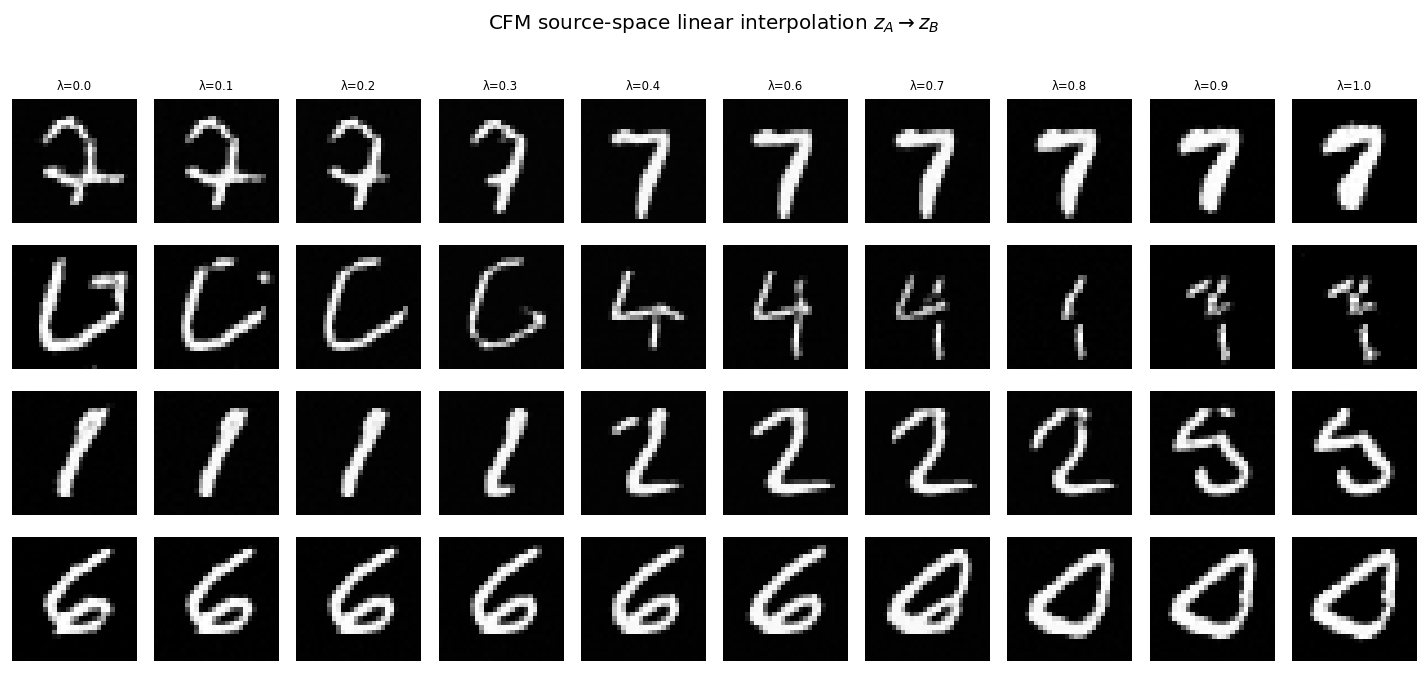

In [9]:
N_INTERP = 10   # interpolation steps
N_PAIRS  = 4    # number of (zA, zB) pairs to show

torch.manual_seed(7)
zA = torch.randn(N_PAIRS, 1, 28, 28, device=DEVICE)
zB = torch.randn(N_PAIRS, 1, 28, 28, device=DEVICE)

lambdas = torch.linspace(0, 1, N_INTERP, device=DEVICE)

fig, axes = plt.subplots(N_PAIRS, N_INTERP, figsize=(N_INTERP * 1.2, N_PAIRS * 1.4))

cfm.eval()
for row in range(N_PAIRS):
    for col, lam in enumerate(lambdas):
        z_interp = (1 - lam) * zA[row:row+1] + lam * zB[row:row+1]
        with torch.no_grad():
            x1 = cfm.sample(
                shape=(1, 1, 28, 28),
                device=DEVICE,
                n_steps=50,
                method='euler',
            )
            # Note: to use fixed z_interp as x_0, we reuse the trajectories API
            # which starts from the given tensor instead of sampling fresh noise
            dt = 1.0 / 50
            x  = z_interp.clone()
            for step in range(50):
                t_val   = torch.tensor(step * dt, device=DEVICE)
                t_batch = t_val.expand(1)
                v       = cfm.network(x, t_batch)
                x       = x + dt * v

        axes[row, col].imshow(denormalize(x).squeeze().cpu().clamp(0,1), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'λ={lam:.1f}', fontsize=7)

fig.suptitle('CFM source-space linear interpolation $z_A \\to z_B$', y=1.01)
plt.tight_layout()
plt.show()

## 7  CFM vs. DDIM-50 — side-by-side

Load the DDPM checkpoint from notebook 05 (if it exists) for a fair comparison.

In [11]:
import pathlib
from diffusion_lab.nn        import SmallUNet
from diffusion_lab.models    import DDPM, DDIMSampler
from diffusion_lab.schedulers import cosine_vp_schedule
from diffusion_lab.training  import Trainer

ckpt_path = pathlib.Path('../checkpoints/ddpm_mnist.pt')

unet_ddpm = SmallUNet(in_channels=1, out_channels=1,
                      base_channels=32, time_embed_dim=128).to(DEVICE)
ddpm_cmp  = DDPM(unet_ddpm, cosine_vp_schedule(T=1000).to(DEVICE)).to(DEVICE)

if ckpt_path.exists():
    tr_tmp = Trainer(ddpm_cmp, train_loader, device=DEVICE)
    tr_tmp.load(str(ckpt_path))
    print(f'Loaded DDPM checkpoint from {ckpt_path}')
else:
    print('No checkpoint found — training DDPM for 5000 steps (quick version)')
    tr_tmp = Trainer(ddpm_cmp, train_loader, lr=2e-4, device=DEVICE)
    tr_tmp.train(n_steps=5_000, log_every=1000)

Loaded DDPM checkpoint from ../checkpoints/ddpm_mnist.pt


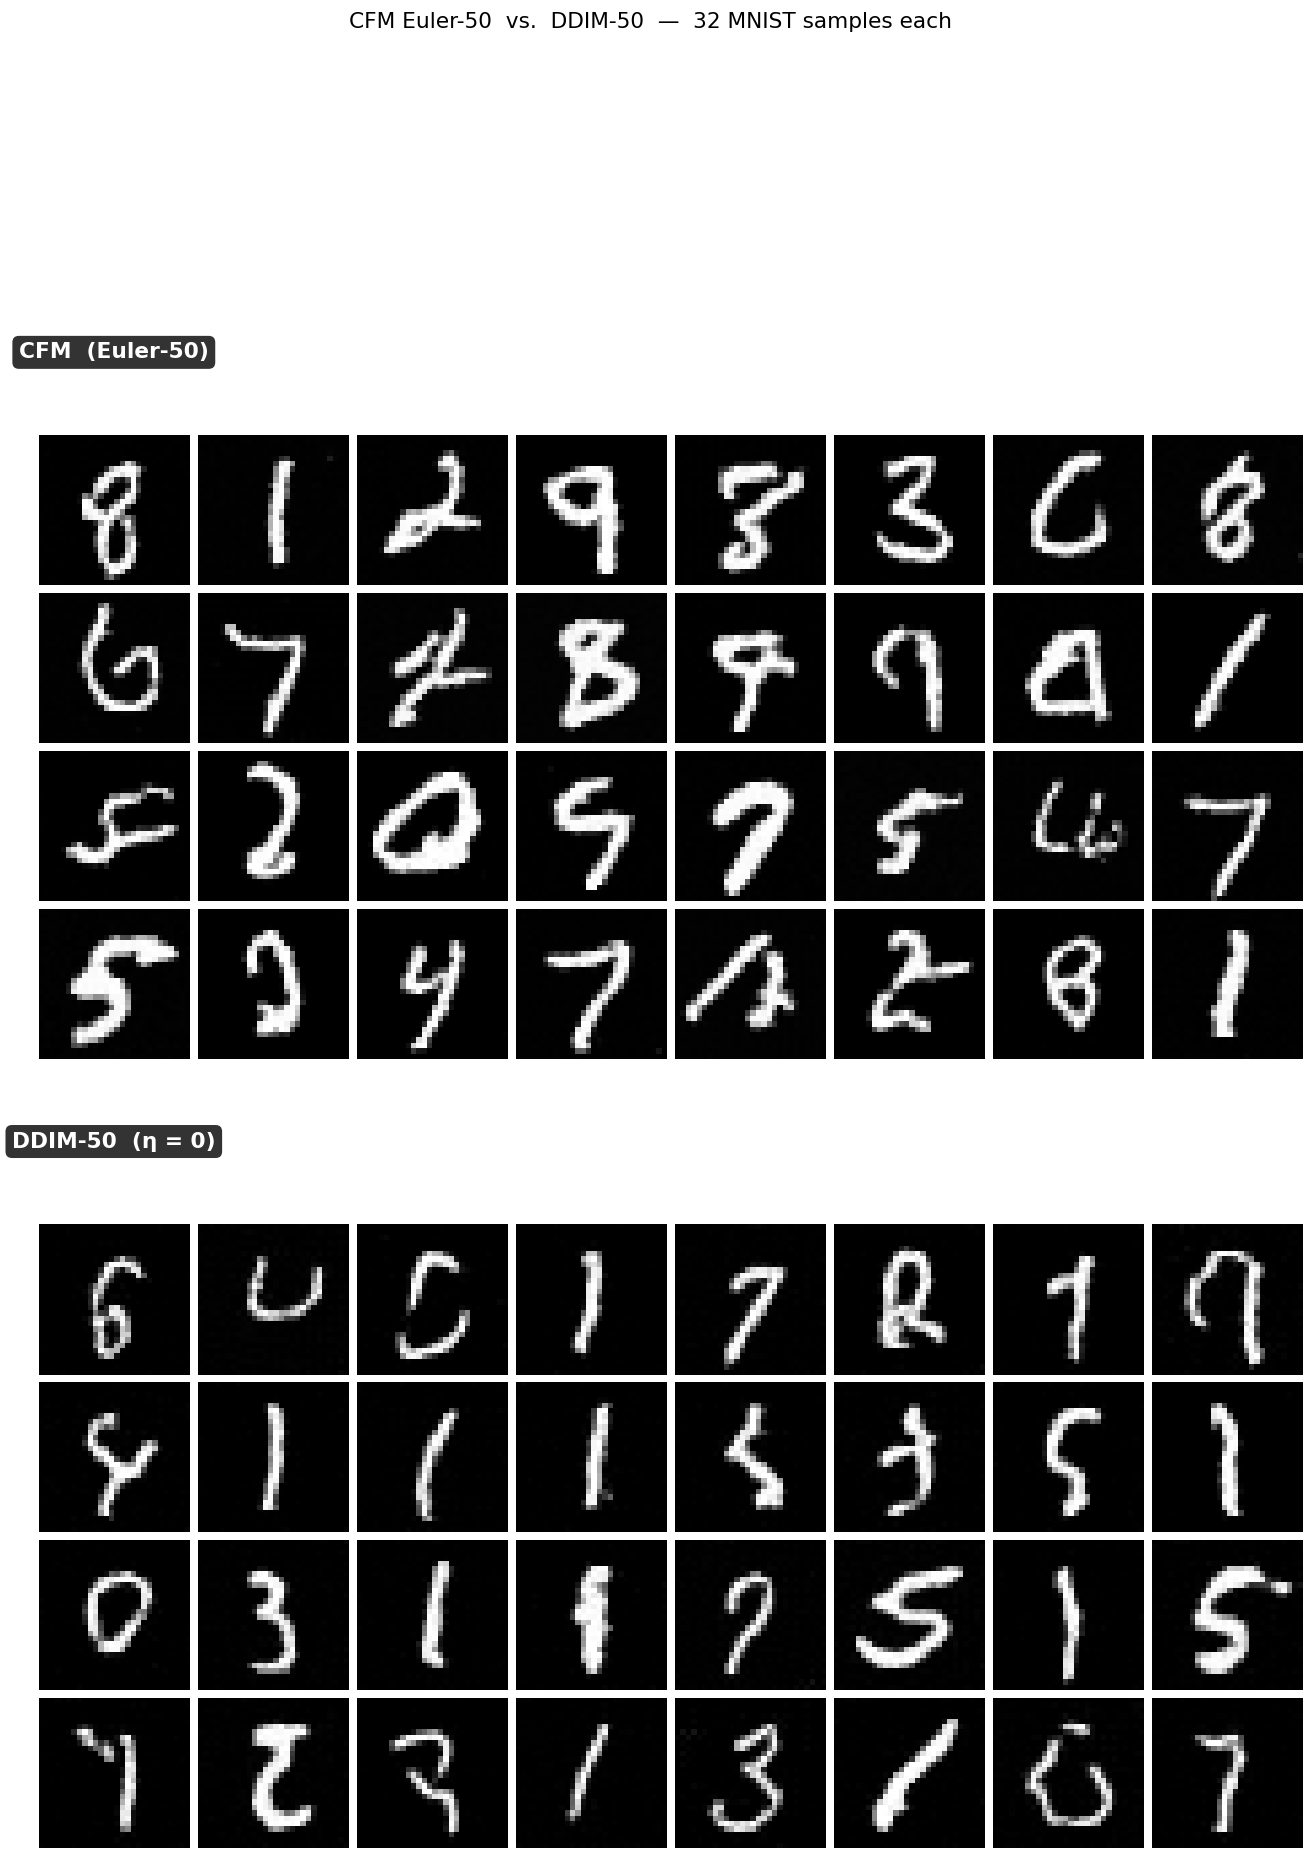

In [18]:
# Generate 32 samples from each model
ddpm_cmp.eval()
cfm.eval()

N_SAMPLES = 32
with torch.no_grad():
    x_cfm50  = cfm.sample((N_SAMPLES, 1, 28, 28), device=DEVICE, n_steps=50, method='euler')
    x_ddim50 = DDIMSampler(ddpm_cmp, eta=0.0, num_steps=50).sample((N_SAMPLES, 1, 28, 28), device=DEVICE)

N_COLS = 8
N_ROWS = N_SAMPLES // N_COLS   # 4

# Two blocks of (N_ROWS × N_COLS), separated by a blank row
# Total rows = 2*(N_ROWS+1) where +1 is a title row for each block
TOTAL_ROWS = 2 * N_ROWS + 2   # 4+4 data rows + 2 label rows

cell_px = 1.7   # inches per image cell
fig, axes = plt.subplots(
    TOTAL_ROWS, N_COLS,
    figsize=(N_COLS * cell_px, TOTAL_ROWS * cell_px),
    gridspec_kw={'hspace': 0.05, 'wspace': 0.05},
)

# Turn off all axes first
for ax in axes.flat:
    ax.axis('off')

def fill_block(row_start, samples, title):
    """Fill one block: title row + N_ROWS image rows."""
    # Title row: span full width via first cell text
    axes[row_start, 0].text(
        N_COLS / 2, 0.5, title,
        transform=axes[row_start, 0].transData,
        fontsize=13, fontweight='bold', ha='center', va='center',
    )
    # Actually easier: use a wide text in the center cell
    for c in range(N_COLS):
        axes[row_start, c].set_visible(False)   # hide all cells in label row
    # Re-use the first cell for the label
    axes[row_start, 0].set_visible(True)
    axes[row_start, 0].set_xlim(0, N_COLS)
    axes[row_start, 0].set_ylim(0, 1)
    axes[row_start, 0].text(
        N_COLS / 2, 0.5, title,
        fontsize=13, fontweight='bold', ha='center', va='center',
        color='white',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#333333', edgecolor='none'),
        transform=axes[row_start, 0].transData,
    )

    # Image rows
    for r in range(N_ROWS):
        for c in range(N_COLS):
            idx = r * N_COLS + c
            ax = axes[row_start + 1 + r, c]
            ax.set_visible(True)
            ax.imshow(denormalize(samples[idx]).squeeze().cpu(),
                      cmap='gray', vmin=0, vmax=1)
            ax.axis('off')

fill_block(row_start=0,          samples=x_cfm50,  title='CFM  (Euler-50)')
fill_block(row_start=N_ROWS + 1, samples=x_ddim50, title='DDIM-50  (η = 0)')

plt.suptitle('CFM Euler-50  vs.  DDIM-50  —  32 MNIST samples each',
             fontsize=13, y=1.01)
# plt.tight_layout()
plt.show()


## 8  Large-scale sample grid — CFM Euler-50

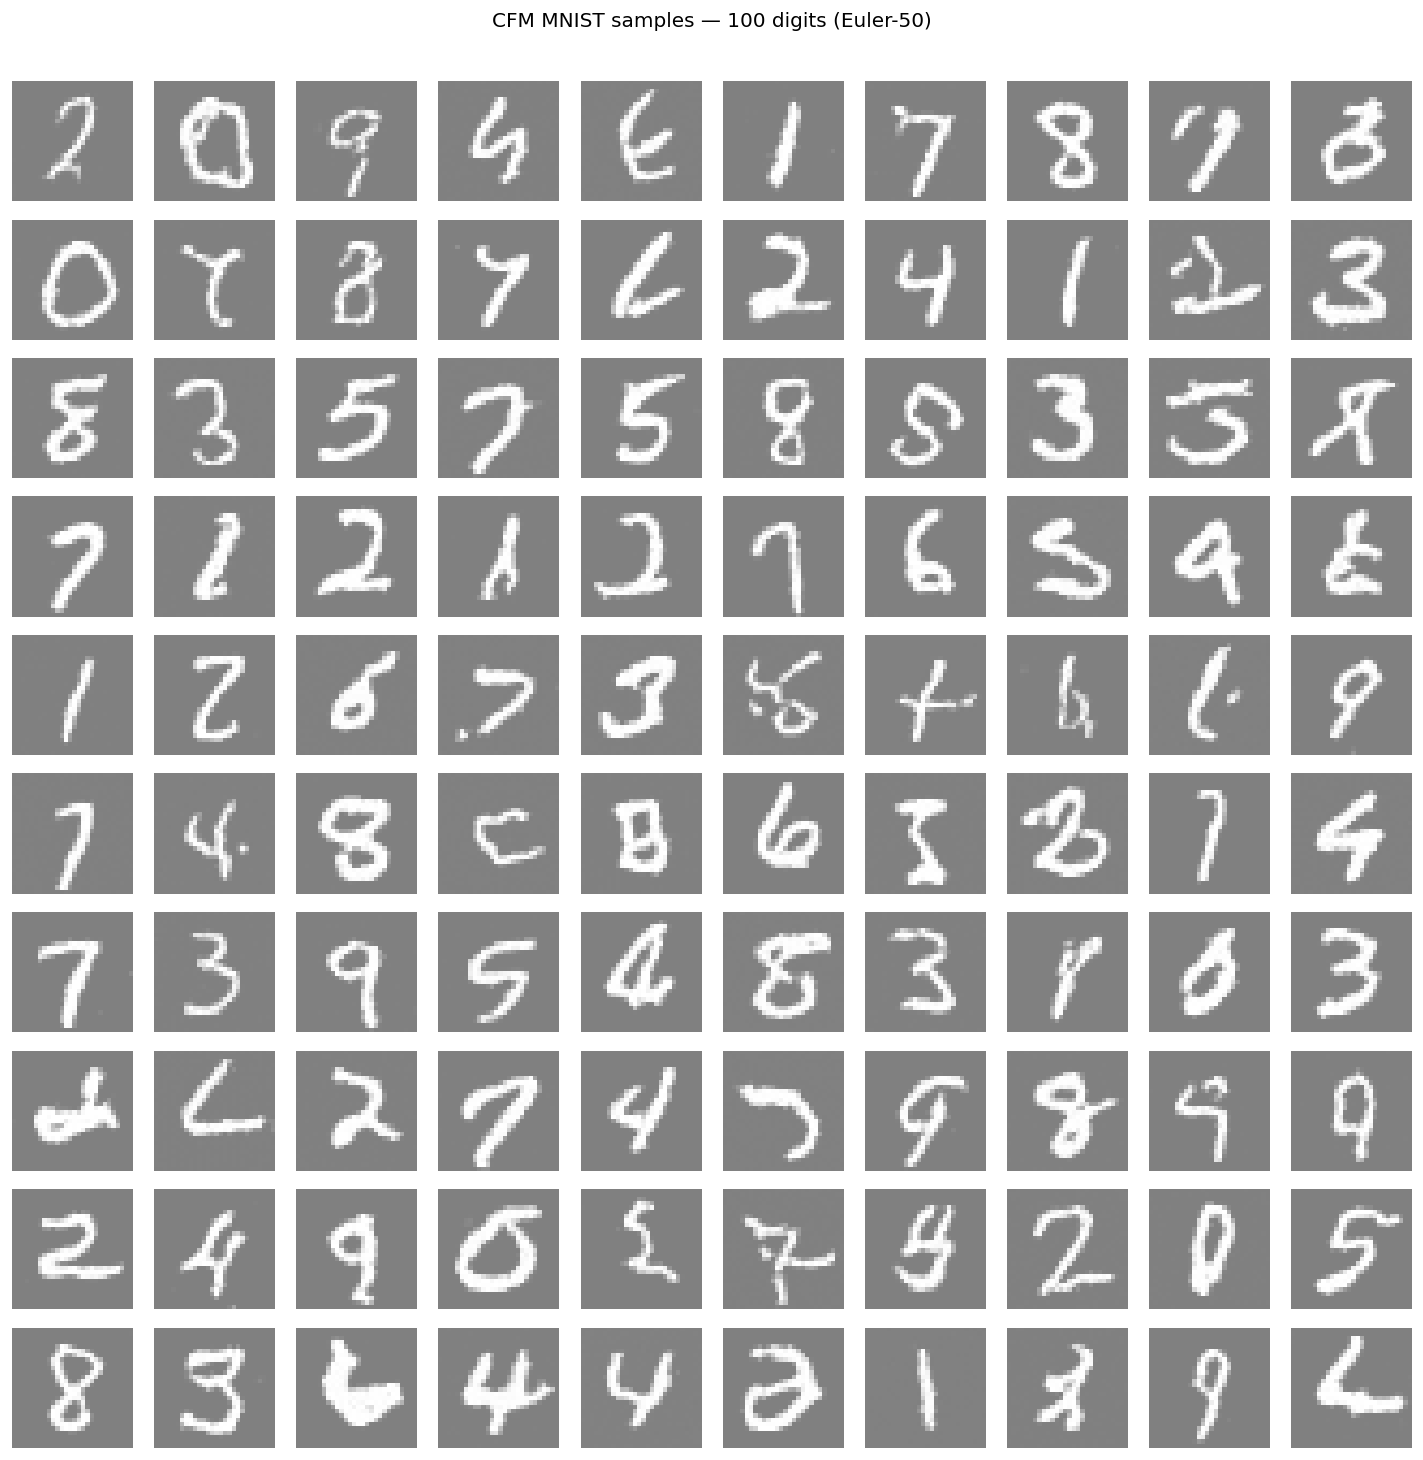

In [19]:
from diffusion_lab.utils import show_grid

with torch.no_grad():
    x_big = cfm.sample((100, 1, 28, 28), device=DEVICE, n_steps=50, method='euler')

fig = show_grid(
    denormalize(x_big).cpu(),
    nrow=10,
    title='CFM MNIST samples — 100 digits (Euler-50)',
)
plt.show()

## 9  Save checkpoint

In [20]:
ckpt_dir = pathlib.Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)
trainer.save(str(ckpt_dir / 'cfm_mnist.pt'))
print('Checkpoint saved to checkpoints/cfm_mnist.pt')

Checkpoint saved to checkpoints/cfm_mnist.pt
